In [ ]:
import torch

# Configure PyTorch to use the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cuda':
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("Memory Allocated:", torch.cuda.memory_allocated(0))
    print("Memory Cached:", torch.cuda.memory_reserved(0))
else:
    print("No GPU devices found. Running on CPU.")


Using device: cuda
GPU Device Name: Tesla T4
Memory Allocated: 0
Memory Cached: 0


In [ ]:
import kagglehub
path = kagglehub.dataset_download("shamimulislamsunny/isic-2024-dataset")

100%|██████████| 2.25G/2.25G [00:23<00:00, 102MB/s]

Extracting files...


In [ ]:
import os
DATA_DIR = os.path.join(path, "hair_removed/train")
TEST_DATA_DIR = os.path.join(path, "hair_removed/test")

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import torch.backends.cudnn as cudnn
import copy

# --- CONFIG ---
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optimize CuDNN for static input sizes
if DEVICE.type == 'cuda':
    cudnn.benchmark = True

# Advanced Medical Augmentation
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Stratified split is critical for imbalanced medical data
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    random_state=42,
    stratify=full_dataset.targets
)

train_dataset = Subset(full_dataset, train_idx)

# Fix: Deepcopy the dataset for validation to prevent overriding train transforms
val_full_dataset = copy.deepcopy(full_dataset)
val_full_dataset.transform = test_transform
val_dataset = Subset(val_full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Total images: {len(full_dataset)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)

# Modify classifier for Binary Classification
in_channels = model.classifier[1].in_channels
model.classifier[1] = nn.Conv2d(in_channels, 2, kernel_size=(1,1), stride=(1,1))
model.num_classes = 2
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler(device='cuda') if torch.cuda.is_available() else torch.amp.GradScaler(device='cpu')

history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item(), acc=correct/total)

    # --- Validation ---
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            v_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    scheduler.step()
    history["loss"].append(running_loss/len(train_loader))
    history["accuracy"].append(correct/total)
    history["val_loss"].append(v_loss/len(val_loader))
    history["val_accuracy"].append(v_correct/v_total)

    print(f"Epoch {epoch+1} -> Train Acc: {correct/total:.4f}, Val Acc: {v_correct/v_total:.4f}")

torch.save(model.state_dict(), "squeezenet_skin_cancer.pth")



Total images: 322498
Train: 257998 | Val: 64500


Epoch 1/20: 100%|██████████| 8063/8063 [04:55<00:00, 27.26it/s, acc=0.993, loss=0.0124]


Epoch 1 -> Train Acc: 0.9933, Val Acc: 0.9939


Epoch 2/20: 100%|██████████| 8063/8063 [04:22<00:00, 30.67it/s, acc=0.994, loss=0.00329]


Epoch 2 -> Train Acc: 0.9939, Val Acc: 0.9939


...

Epoch 18 -> Train Acc: 0.9939, Val Acc: 0.9939


Epoch 19/20: 100%|██████████| 8063/8063 [04:07<00:00, 32.57it/s, acc=0.994, loss=nan]


Epoch 19 -> Train Acc: 0.9939, Val Acc: 0.9939


Epoch 20/20: 100%|██████████| 8063/8063 [04:06<00:00, 32.69it/s, acc=0.994, loss=nan]


Epoch 20 -> Train Acc: 0.9939, Val Acc: 0.9939



--- IMPORTANT: NaN values detected in training history. This indicates an issue during model training. ---


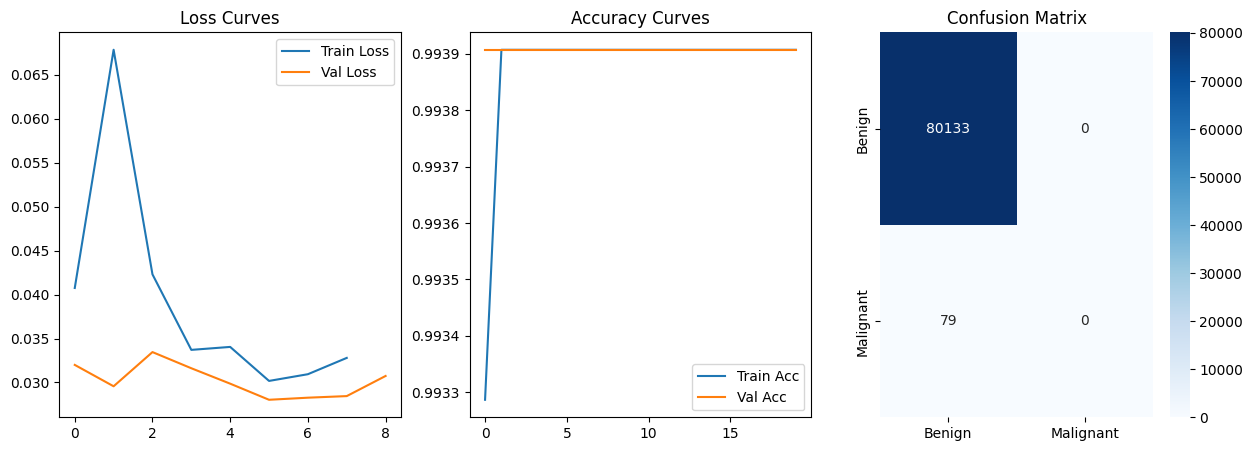


Test Set ROC-AUC: 0.5000
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     80133
   Malignant       0.00      0.00      0.00        79

    accuracy                           1.00     80212
   macro avg       0.50      0.50      0.50     80212
weighted avg       1.00      1.00      1.00     80212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
test_dataset = datasets.ImageFolder(TEST_DATA_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
y_probs, y_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        # Ensure outputs do not contain NaNs before softmax
        if torch.isnan(outputs).any():
            print("Warning: Model outputs contain NaN values during testing. Replacing with zeros.")
            outputs[torch.isnan(outputs)] = 0.0 # Or some other reasonable default

        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        y_probs.extend(probs)
        y_true.extend(labels.numpy())

y_probs, y_true = np.array(y_probs), np.array(y_true)

# Handle NaN values in y_probs before using them in sklearn metrics
if np.isnan(y_probs).any():
    print("Warning: y_probs contains NaN values. Replacing with 0.5 to proceed with metrics calculation.")
    y_probs = np.nan_to_num(y_probs, nan=0.5)

y_pred = (y_probs > 0.5).astype(int)

# Check for NaNs in history and inform the user
if any(np.isnan(history[key]).any() for key in history):
    print("\n--- IMPORTANT: NaN values detected in training history. This indicates an issue during model training. ---")

# --- VISUALS ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history["loss"], label='Train Loss')
plt.plot(history["val_loss"], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["accuracy"], label='Train Acc')
plt.plot(history["val_accuracy"], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.show()

print(f"\nTest Set ROC-AUC: {auc(roc_curve(y_true, y_probs)[0], roc_curve(y_true, y_probs)[1]):.4f}")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))